# Phase 2 - Data Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
from scipy.stats.mstats import winsorize
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import statsmodels.stats as sm_stats
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.model_selection import cross_val_score

plt.rcParams["font.family"] = "DejaVu Sans"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [5]:
def read_any(path):
    try:
        return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        return pd.read_csv(path, sep=";", engine="python", encoding="utf-8-sig")

patient = read_any("data/patient.csv")
station = read_any("data/station.csv")
observation = read_any("data/observation.csv")


## 2.1 Implementing Data Preprocessing

# A


In [6]:
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series >= lower) & (series <= upper)]


low_outlier_columns = ["SpO₂","PI","RR","PRV","Skin Temperature","Motion/Activity index","PVI","Hb level","SV","Blood Flow Index", "PPG waveform features","Signal Quality Index", "Respiratory effort"]
for column in low_outlier_columns:
    data = observation[column]
    data_without_outliers = remove_outliers_iqr(data)


def removing_outliers_low_percentatge(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        if col in cleaned_df.columns:
            Q1 = cleaned_df[col].quantile(0.25)
            Q3 = cleaned_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            before = len(cleaned_df)
            cleaned_df = cleaned_df[(cleaned_df[col] >= lower) & (cleaned_df[col] <= upper)]
            after = len(cleaned_df)

    return cleaned_df

In [7]:
observation_clean = removing_outliers_low_percentatge(observation, low_outlier_columns)

In [8]:
observation_clean.shape

(11118, 23)

The cleaned dataset was divided into a training, validating and testing set using an 60/20/20 ratio. We do this separation in order to compare models with the validation part in section 3. Test set will be only used to evaluate final performance of our best model, and not to compare models.
The target variable is oximetry, representing a binary classification problem (critical vs. normal state).
Stratified sampling was applied to preserve the class balance between both sets.

In [9]:
X = observation_clean.drop(columns=['oximetry'])
y = observation_clean['oximetry']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=11, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=11, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (6670, 22)
Validation set: (2224, 22)
Test set: (2224, 22)


# B

- The dataset observation_clean contains 23 numerical attributes and 11,118 records.
- An initial inspection using .info() and .isna() confirms that there are no missing values in any of the columns.
- All features are stored as float64, making the dataset already suitable for machine learning algorithms
- **(To be eliminated) Three columns: SpO₂ (is directly related to the target variable and could cause data leakage), latitude, and longitude (contain location metadata irrelevant for the classification task) were dropped from the predictors**

In [10]:
observation_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11118 entries, 0 to 12045
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   11118 non-null  float64
 1   HR                     11118 non-null  float64
 2   PI                     11118 non-null  float64
 3   RR                     11118 non-null  float64
 4   EtCO₂                  11118 non-null  float64
 5   FiO₂                   11118 non-null  float64
 6   PRV                    11118 non-null  float64
 7   BP                     11118 non-null  float64
 8   Skin Temperature       11118 non-null  float64
 9   Motion/Activity index  11118 non-null  float64
 10  PVI                    11118 non-null  float64
 11  Hb level               11118 non-null  float64
 12  SV                     11118 non-null  float64
 13  CO                     11118 non-null  float64
 14  Blood Flow Index       11118 non-null  float64
 15  PPG wav

In [11]:
display(observation_clean.isna().sum().sort_values(ascending=False))

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64

In [12]:
print(X.isna().sum().sum()) 

0


In [13]:
print("Final numeric dataset shape:", X.shape)

Final numeric dataset shape: (11118, 22)


# C

Before doing any preprocessing, we want to look at our target variable to see its distribution. We want to see if we have imbalance on our target variable. This is useful information for us right now because we will use some basic models to test preprocessing techniques.

In [14]:
print(observation_clean['oximetry'].value_counts())

oximetry
1.0    6608
0.0    4510
Name: count, dtype: int64


We can see that aproximately 60% of our data belongs to class1 (oximetry 1) and 40% to class 2 (oximetry 0). This is not an extreme case, so we won't apply any sampling technique, but we'll take into account the situation when we adjust our models and select out metriques.

To prepare the data for machine learning, several feature transformation techniques were applied and evaluated.

**Two main categories of preprocessing are tested**
- Scaling methods: No scaling, StandardScaler and MinMaxScaler
- Transformers: No transformation, PowerTransformer (Yeo–Johnson) and Quantile Transformers

**How we are going to evaluate each preprocessing?**
- We are going to combine each type of precprocessing (each type of scaling with each type of transformer)
- We are going to use Logistic Regression on each combination
- We are going to sort combination with the F1 metric score (in order not to suffer from imbalance, as previously mentioned)

In [15]:
scalers = {
    "none": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
}

transformers = {
    "none": None,
    "power": PowerTransformer(method='yeo-johnson'),
    "quantile": QuantileTransformer(output_distribution='normal', random_state=11),
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']

In [16]:
for s_name, scaler in scalers.items():
    for t_name, transformer in transformers.items():
        steps = []

        if scaler is not None:
            steps.append(("scaler", scaler))
        if transformer is not None:
            steps.append(("transformer", transformer))

        steps.append(("clf", LogisticRegression(max_iter=1000, random_state=11)))

        pipe = Pipeline(steps)
        combo_name = f"{s_name} + {t_name}"

        scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        mean_scores = {metric: np.mean(scores[f"test_{metric}"]) for metric in scoring}

        results.append({
            "combination": combo_name,
            **mean_scores
        })

        print(f"Done: {combo_name} | F1_macro: {mean_scores['f1_macro']:.4f}")

Done: none + none | F1_macro: 0.8380
Done: none + power | F1_macro: 0.8451
Done: none + quantile | F1_macro: 0.8385
Done: standard + none | F1_macro: 0.8442
Done: standard + power | F1_macro: 0.8458
Done: standard + quantile | F1_macro: 0.8385
Done: minmax + none | F1_macro: 0.8444
Done: minmax + power | F1_macro: 0.8458
Done: minmax + quantile | F1_macro: 0.8385


From the results we can see clearly that Power tranformation gets better results than quantile and there is no much difference between minmax and standard.

In [17]:
results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

print("\nTop 3 combinations by F1 score:")
print(results_df.head(3))


Top 3 combinations by F1 score:
        combination  accuracy  precision_macro  recall_macro  f1_macro   roc_auc
0  standard + power  0.851724         0.847037      0.844821  0.845793  0.921875
1    minmax + power  0.851874         0.847468      0.844477  0.845792  0.921865
2      none + power  0.851124         0.846556      0.843964  0.845104  0.921602


As we can see, all preprocessings with power transformation are the best ones.

In [18]:
pipe1 = Pipeline([
    ('scale', StandardScaler()),
    ('transform', PowerTransformer()),
])

pipe2 = Pipeline([
    ('scale', MinMaxScaler()),
    ('transform', PowerTransformer()),
])

**We are going to stay with the standard + power preprocessing (pipe1).** However, later on we can consider to use the second best preprocessing (pipe2) to compare models performance. Let's analyze data using pipe1.

In [19]:
X_train_preprocessed = pipe1.fit_transform(X_train)
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=X_train.columns)
print(X_train_preprocessed_df.describe().T)
X_train_preprocessed_df.skew()

                        count          mean       std       min       25%       50%       75%       max
SpO₂                   6670.0 -2.024035e-17  1.000075 -2.750517 -0.693058 -0.004594  0.701611  2.751128
HR                     6670.0  7.989611e-18  1.000075 -4.090687 -0.637382 -0.007103  0.645700  4.561189
PI                     6670.0  1.917507e-17  1.000075 -2.673863 -0.681714 -0.000110  0.683240  2.759196
RR                     6670.0 -1.518026e-17  1.000075 -3.123349 -0.794835  0.010143  0.779909  2.904192
EtCO₂                  6670.0  2.343619e-17  1.000075 -2.874393 -0.753122 -0.040358  0.824478  2.905850
FiO₂                   6670.0 -5.859048e-18  1.000075 -4.163418 -0.679526  0.007687  0.667694  4.020940
PRV                    6670.0 -1.278338e-17  1.000075 -2.746460 -0.685784  0.003427  0.682958  2.765077
BP                     6670.0  2.024035e-17  1.000075 -2.945533 -0.796207 -0.088809  0.858687  2.589488
Skin Temperature       6670.0  4.261126e-18  1.000075 -2.578942 

SpO₂                    -0.000855
HR                       0.003074
PI                       0.003965
RR                       0.015408
EtCO₂                   -0.027568
FiO₂                     0.002185
PRV                     -0.001188
BP                       0.011206
Skin Temperature        -0.008466
Motion/Activity index    0.001185
PVI                     -0.002524
Hb level                -0.000194
SV                      -0.004901
CO                       0.705256
Blood Flow Index        -0.001856
PPG waveform features   -0.004122
Signal Quality Index    -0.000141
Respiratory effort      -0.001443
O₂ extraction ratio      0.004556
SNR                     -0.002456
latitude                -0.090831
longitude                0.006583
dtype: float64

Now we can see how all variables have similar ranges (between -4 and 4) and are normally distributed (no skew greater than 1 or lower than -1). Also, we can see that all variables have 0 mean and 1 std.

<!-- To prepare the data for machine learning, several feature transformation techniques were applied and evaluated.

**Two main categories of preprocessing were tested together with a Logistic Regression classifier:**
- Scaling methods: StandardScaler and MinMaxScaler
- Transformers: PowerTransformer (Yeo–Johnson) and PCA (Principal Component Analysis)

**Scaling Techniques**
- Both scalers achieved nearly identical results, with accuracy around 0.85, precision around 0.84–0.85, and f1-score around 0.85.
This indicates that the model performs similarly under both scaling methods and that the features are relatively well-behaved numerically.

**Transformation Techniques**
- The PowerTransformer achieved slightly better overall performance (accuracy = 0.85) compared to PCA (accuracy = 0.84).
This suggests that normalizing skewed distributions was more effective than dimensionality reduction in this dataset. -->

# D

**Data Selection and Structure**

The analysis focused on the observation_clean dataset, which contained all relevant physiological attributes in numeric form.
Files (station, patient) were excluded from the preprocessing pipeline because they contained data not essential for modeling oxygen saturation states.

**Data Cleaning**

An inspection with .info() and .isna() confirmed that the dataset had no missing values and all columns were of type float64.
This eliminated the need for imputation or categorical encoding.

**Why have we selected these type of preprocessing (scaling and transformers)?**
- We look at our data to justify our decisions 

In [20]:
X_train.describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,PVI,Hb level,SV,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude
count,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000,6670.000000
mean,97.422216,80.047575,9.851578,16.075405,40.198889,59.865292,113.089439,104.276227,35.751149,10.274533,14.524456,14.891393,79.626717,4.017266,48.414345,54.185383,46.671182,50.188763,0.249394,29.977002,28.245568,12.079311
std,0.602860,4.475221,2.644281,1.148425,1.658119,9.219745,22.387400,5.443275,0.837339,0.966621,1.161168,0.803892,5.401224,0.072340,13.471151,12.055351,12.039345,12.997632,0.028981,5.763520,23.402158,74.161391
min,95.775265,61.348778,2.676847,12.716268,35.000000,21.000000,51.641938,90.000000,33.281944,7.626619,11.401530,12.674120,64.902369,4.000000,11.137252,20.190594,13.178743,14.372306,0.200000,20.000636,-54.800000,-123.026210
25%,97.003508,77.213929,8.058957,15.154210,38.982770,53.620263,97.734732,99.877320,35.099758,9.629065,13.723364,14.339028,75.950191,4.002274,39.035079,45.684228,38.408646,41.370983,0.224224,24.917886,14.625780,-56.523610
50%,97.417316,80.050850,9.872240,16.050555,40.204796,59.978357,113.159633,103.472897,35.847902,10.268191,14.511203,14.886334,79.583648,4.005519,48.333378,53.947286,46.557854,50.025417,0.248726,30.015971,35.815000,9.592600
75%,97.844233,82.953913,11.667318,16.957116,41.577529,66.040268,128.374979,108.849219,36.395596,10.934449,15.314633,15.445695,83.385796,4.014155,57.891720,62.837528,54.864414,59.044232,0.274800,34.978912,45.433410,73.383330
max,99.091848,100.000000,17.037906,19.628727,44.626571,96.488988,175.022166,120.000000,37.965570,12.912545,17.748276,17.098845,94.243193,8.000000,84.945764,88.741606,80.005097,86.331449,0.300000,40.000000,68.798330,171.253640


As we can see, our variable had very different ranges. An example of this is HR (min: 61, max: 100) and O2(min: 0.2, max: 0.3). This can be bad for some models and produce bad results. Because of that, we have performed scaling with StandardScaler and MinMaxScaler to deal with this problem.

In [21]:
X_train.skew()

SpO₂                      0.015387
HR                       -0.045520
PI                       -0.032389
RR                        0.126523
EtCO₂                    -0.173021
FiO₂                     -0.024188
PRV                       0.000166
BP                        0.189603
Skin Temperature         -0.256783
Motion/Activity index    -0.002732
PVI                       0.010524
Hb level                 -0.004599
SV                       -0.017978
CO                       32.171494
Blood Flow Index          0.005252
PPG waveform features    -0.005799
Signal Quality Index      0.035740
Respiratory effort        0.020814
O₂ extraction ratio       0.026429
SNR                      -0.018659
latitude                 -1.057918
longitude                -0.000986
dtype: float64

In the cell before we have calculated the skew of all attributes. From the values, we see that almost all attributes are already normally distributed with very little skew (most of them lower than 1 (and higher -1) and only a few ones between -0.2 and 0.2). However, there is two variables which have more problems: latitude (-1.07) and specially CO (33 aprox). This could be also a problem because some models benefit from this type of distribution. Because of that, we have applied Power Transform and Quintile Transform. 

**Why have we used Logistic Regression? Why only on train set?**

What we have done here is crossvalidation only in the training set. This means, we have created sub partitions inside the training set in a way that we fitted the logistic regression is some of this partitios and predicted on the other partitions which were not used to fit. This allowed us to compute and compare rigorous results with our preprocessings. We used Logistic Regression because it is a basic model which is really sensitive to scaling and normal distributions. Thus, the model achieves to evaluate really well our preoprocessings. 

**Why have we used F1 score to compare models?**

As we saw in the beginning of 2.1 C), our dataset was not really imbalanced towrds one target class, but was not also perfectly balanced. For this reason, we decided to use F1, which balances takes into account really well both Precision and Recall results, in order to compare models. F1 allows us to have a rigorous metric although having a bit of imbalance.

<!-- **Data Selection and Structure**

The analysis focused on the observation_clean dataset, which contained all relevant physiological attributes in numeric form.
Files (station, patient) were excluded from the preprocessing pipeline because they contained data not essential for modeling oxygen saturation states.

**Data Cleaning**

An inspection with .info() and .isna() confirmed that the dataset had no missing values and all columns were of type float64.
This eliminated the need for imputation or categorical encoding.

**Feature Preparation**

The target variable was defined as oximetry, representing a binary classification problem. SpO₂ (directly related to the target and would cause data leakage), latitude and longitude (provide only metadata without physiological meaning)
were removed. -->
<!-- 
**Scaling and Transformation**

Four transformation approaches were tested:
- StandardScaler – normalization to zero mean and unit variance.
- MinMaxScaler – scaling to a [0, 1] range.
- PowerTransformer (Yeo–Johnson) - was chosen to adjust for skewed distributions of numerical attributes, which allows linear models to better capture relationships in the data and reduce the impact of extreme values.
- Principal Component Analysis - was used as a dimensionality reduction. It simplifies data by removing redundancy between correlated attributes. It creates a smaller dataset that still contains the essential information. -->

### 2.2 Feature Selection for Machine Learning

# A

**Mutual Information**

EtCO₂                    0.285378
Skin Temperature         0.143771
RR                       0.069114
BP                       0.028856
HR                       0.010787
CO                       0.009837
Respiratory effort       0.009306
Signal Quality Index     0.008153
SpO₂                     0.008139
PVI                      0.007707
PPG waveform features    0.005647
Hb level                 0.005182
PI                       0.005176
Motion/Activity index    0.004539
FiO₂                     0.003003
PRV                      0.002813
SNR                      0.002472
SV                       0.001701
Blood Flow Index         0.000301
O₂ extraction ratio      0.000186
latitude                 0.000000
longitude                0.000000
dtype: float64


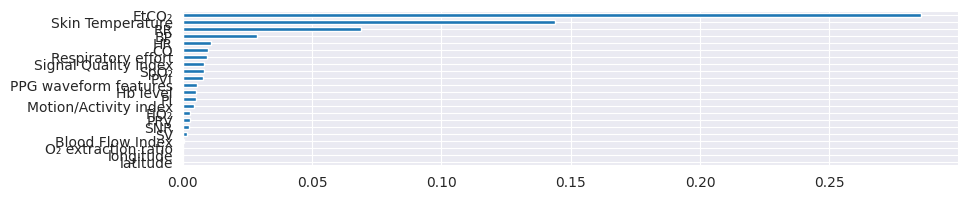

In [22]:
selector = mutual_info_classif(X_train_preprocessed_df, y_train)
scores = pd.Series(selector, index=X_train_preprocessed_df.columns).sort_values()

plt.figure(figsize=(10,2))
scores.plot(kind='barh')
print(scores.sort_values(ascending=False))

Here we can see that there is two variable which have no relation with the target variable. This variables are latitude and longitude. This two are does not help to predict the target variable and are just noise, se we will continue without them. 

**(ANOVA) F Score and P value**

In [23]:
cols_to_drop = ["latitude", "longitude"]
X_train_after_mi = X_train_preprocessed_df.drop(columns=cols_to_drop)

In [24]:
# Compute F-values and p-values
f_values, p_values = f_classif(X_train_preprocessed_df, y_train)

# Create a DataFrame for easier inspection
anova_df = pd.DataFrame({
    "Feature": X_train_preprocessed_df.columns,
    "F_value": f_values,
    "p_value": p_values
}).sort_values(by="F_value", ascending=False)

# Display
display(anova_df)

,Feature,F_value,p_value
4,EtCO₂,5209.994302,0.000000e+00
8,Skin Temperature,1089.884816,1.632142e-221
3,RR,609.308114,8.290116e-129
5,FiO₂,120.782520,7.386110e-28
7,BP,74.693106,6.805192e-18
17,Respiratory effort,6.596899,1.023722e-02
15,PPG waveform features,2.675240,1.019671e-01
9,Motion/Activity index,2.196860,1.383394e-01
20,latitude,2.078873,1.493973e-01
19,SNR,1.846185,1.742738e-01


As we can see in the table before, there is a most of to variables have p-value >  0.05. This means that, for that variables, there is no statistical evidence that the mean of observations of both groups (Oximetry and not oximetry) are different for that variables. Moreover, F1-values are really low one some values. We should consider not using those variables. However, there is a lot of them and it would be such a risky step to get rid of all of them. For this reason, we'll mantain all and decide if remove them or not after the nexts feature selection steps.

What we are going to do now is apply feature selection with RFE, SFS and SBS wrapped feature selection methods, which are more advanced, in order to do a comparation between them. We want to compare them and see if we should get rid off those variables which had p-value > 0.5 in the previous section.

**RFE with Random Forest**

In [25]:
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
selector = RFE(estimator, n_features_to_select=5, step=1)


selector = selector.fit(X_train_after_mi, y_train)

selected_mask = selector.support_
ranking = selector.ranking_
feature_ranking = pd.DataFrame({
    'Feature': X_train_after_mi.columns,
    'Selected': selected_mask,
    'Ranking': ranking
})

print(feature_ranking.sort_values('Ranking'))
print("\nSelected features:")
print(feature_ranking[feature_ranking['Selected'] == True]['Feature'].tolist())

                  Feature  Selected  Ranking
3                      RR      True        1
7                      BP      True        1
5                    FiO₂      True        1
4                   EtCO₂      True        1
8        Skin Temperature      True        1
1                      HR     False        2
13                     CO     False        3
12                     SV     False        4
19                    SNR     False        5
17     Respiratory effort     False        6
18    O₂ extraction ratio     False        7
14       Blood Flow Index     False        8
11               Hb level     False        9
0                    SpO₂     False       10
10                    PVI     False       11
16   Signal Quality Index     False       12
6                     PRV     False       13
9   Motion/Activity index     False       14
2                      PI     False       15
15  PPG waveform features     False       16

Selected features:
['RR', 'EtCO₂', 'FiO₂', 'BP', 'Skin

If we want to select 5 features with RFE, those selected are the ones with p-value < 0.5 in the previous section, so both feeatre selections have made them same decision. Let's see the other two.

**SFS**

In [27]:
estimator = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
sfs1 = SFS(estimator, k_features=5, forward=True, floating=False, verbose=2, scoring='f1', cv=5)
sfs1 = sfs1.fit(X_train_after_mi, y_train)


feat_names = X_train_after_mi.columns.tolist() if hasattr(X_train_after_mi, "columns") else [f"X{i}" for i in range(X_train_after_mi.shape[1])]
selected_mask = [i in sfs1.k_feature_idx_ for i in range(len(feat_names))]
selection_order = {i: (list(sfs1.k_feature_idx_).index(i)+1) if i in sfs1.k_feature_idx_ else None 
                   for i in range(len(feat_names))}

feature_table = pd.DataFrame({
    'Feature': feat_names,
    'Selected': selected_mask,
    'Selection_Order': [selection_order[i] for i in range(len(feat_names))]
}).sort_values(by=['Selected', 'Selection_Order'], ascending=[False, True])


print(feature_table)

print("\nSelected features:")
print([feat_names[i] for i in sfs1.k_feature_idx_])

[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:   17.5s finished

[2025-11-09 15:40:39] Features: 1/5 -- score: 0.7871248681565357[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:   14.0s finished

[2025-11-09 15:40:53] Features: 2/5 -- score: 0.8579483609508033[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed:   13.0s finished

[2025-11-09 15:41:06] Features: 3/5 -- score: 0.8985484827115842[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:   12.9s finished

[2025-11-09 15:41:19] Features: 4/5 -- score: 0.9200456239259708

                  Feature  Selected  Selection_Order
3                      RR      True              1.0
4                   EtCO₂      True              2.0
5                    FiO₂      True              3.0
7                      BP      True              4.0
8        Skin Temperature      True              5.0
0                    SpO₂     False              NaN
1                      HR     False              NaN
2                      PI     False              NaN
6                     PRV     False              NaN
9   Motion/Activity index     False              NaN
10                    PVI     False              NaN
11               Hb level     False              NaN
12                     SV     False              NaN
13                     CO     False              NaN
14       Blood Flow Index     False              NaN
15  PPG waveform features     False              NaN
16   Signal Quality Index     False              NaN
17     Respiratory effort     False           

[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:   12.2s finished

[2025-11-09 15:41:31] Features: 5/5 -- score: 0.9290032181522033

Here the same 5 are selected.

**SBS**

In [28]:
estimator = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
sfs1 = SFS(estimator, k_features=5, forward=False, floating=False, verbose=2, scoring='f1', cv=5)
sfs1 = sfs1.fit(X_train_after_mi, y_train)


feat_names = X_train_after_mi.columns.tolist() if hasattr(X_train_after_mi, "columns") else [f"X{i}" for i in range(X_train_after_mi.shape[1])]
selected_mask = [i in sfs1.k_feature_idx_ for i in range(len(feat_names))]
selection_order = {i: (list(sfs1.k_feature_idx_).index(i)+1) if i in sfs1.k_feature_idx_ else None 
                   for i in range(len(feat_names))}

feature_table = pd.DataFrame({
    'Feature': feat_names,
    'Selected': selected_mask,
    'Selection_Order': [selection_order[i] for i in range(len(feat_names))]
}).sort_values(by=['Selected', 'Selection_Order'], ascending=[False, True])


print(feature_table)

print("\nSelected features:")
print([feat_names[i] for i in sfs1.k_feature_idx_])

[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:   18.9s finished

[2025-11-09 15:42:02] Features: 19/5 -- score: 0.9226987974032651[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:   17.8s finished

[2025-11-09 15:42:20] Features: 18/5 -- score: 0.9246509478631253[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed:   17.0s finished

[2025-11-09 15:42:37] Features: 17/5 -- score: 0.9262572657268423[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:   15.8s finished

[2025-11-09 15:42:53] Features: 16/5 -- score: 0.9263272584992259[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:   13.7s finished

[2025-11-09 15:43:06] Features: 15/5 -- score: 0.9256086310962164[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:   13.1s finished

[2025-11-09 15:43:20] Features: 14/5 -- score: 0.9257843056254295[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:   11.7s finished

[2025-11-09 15:43:31] Features: 13/5 -- score: 0.9291260442128397[Parallel(n_jobs=1)]: Done  13 out of  13 | elap

                  Feature  Selected  Selection_Order
3                      RR      True              1.0
4                   EtCO₂      True              2.0
5                    FiO₂      True              3.0
7                      BP      True              4.0
8        Skin Temperature      True              5.0
0                    SpO₂     False              NaN
1                      HR     False              NaN
2                      PI     False              NaN
6                     PRV     False              NaN
9   Motion/Activity index     False              NaN
10                    PVI     False              NaN
11               Hb level     False              NaN
12                     SV     False              NaN
13                     CO     False              NaN
14       Blood Flow Index     False              NaN
15  PPG waveform features     False              NaN
16   Signal Quality Index     False              NaN
17     Respiratory effort     False           

[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    4.3s finished

[2025-11-09 15:44:33] Features: 5/5 -- score: 0.9290032181522033

Same for SBS. We can see that the three methods gave us the same results, which gives us confidence that we are doing the correct thing by not using those variables. However, let's decide if use them or not by looking at the performance using the Logistic Regression model, like we done before.

Also in this part we'll decide if use dimensionality reduction (PCA) also as feature selection with the variables, in order to see if its beneficial or not for the study.

In [29]:
selected_features = feature_table[feature_table['Selected']]['Feature'].tolist()
subsets = {
    'Selected only': selected_features,
    'All features': X_train_after_mi.columns.tolist()
}

results = []

for name, cols in subsets.items():
    X_subset = X_train_after_mi[cols]
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(lr, X_subset, y_train, cv=5, scoring='f1')
    results.append({'Subset': name, 'PCA': 'No', 'Mean F1': scores.mean(), 'Std': scores.std()})
    
    # 2️⃣ With PCA
    pca = PCA(n_components=min(len(cols), X_subset.shape[0]))  # cannot have more components than samples
    X_pca = pca.fit_transform(X_subset)
    scores_pca = cross_val_score(lr, X_pca, y_train, cv=5, scoring='f1')
    results.append({'Subset': name, 'PCA': 'Yes', 'Mean F1': scores_pca.mean(), 'Std': scores_pca.std()})

results_df = pd.DataFrame(results).sort_values('Mean F1', ascending=False)
print(results_df)

          Subset  PCA   Mean F1       Std
3   All features  Yes  0.876100  0.006150
2   All features   No  0.876100  0.006150
1  Selected only  Yes  0.875847  0.005504
0  Selected only   No  0.875847  0.005504


From here we can make some conclusions:
- There is no much difference in performance betwen using all features and the selected ones only
- There is no much difference in performance with and without PCA

All features gives us slightly better results, but not sufficient to make us think we have to continue with them. This means that the selected features are sufcient to explain the target variable.

Talking about dimensionality reduction, it is not worth it to perform ir as it does not improve a lot and we lose interpretability.

Thus, our decision is to continue with with the selected features and without PCA.

In [30]:
cols_to_keep = ['RR', 'EtCO₂', 'FiO₂', 'BP', 'Skin Temperature']
X_train_after_feature_selection = X_train_after_mi[cols_to_keep].copy()

print("Columns kept:", X_train_after_feature_selection.columns.tolist())

Columns kept: ['RR', 'EtCO₂', 'FiO₂', 'BP', 'Skin Temperature']


So these are the variables which are informative about the target.

# B

In order to rank the selected variables, we will look at the feature selection methods we performed, which already gave us a ranking.

## C

**Which feature selection methods have we used and why?**

We have decided to do the following feature selection process.

**Why not use variance treshold?**

### 2.3 Preprocessing replicability

In [31]:

X_train_clean = X_train.drop(columns=['latitude', 'longitude'])
X_val_clean = X_val.drop(columns=['latitude', 'longitude'])
X_test_clean = X_test.drop(columns=['latitude', 'longitude'])

cols_final = ['RR', 'EtCO₂', 'FiO₂', 'BP', 'Skin Temperature']
X_train_selected = X_train_clean[cols_final]
X_val_selected = X_val_clean[cols_final]
X_test_selected = X_test_clean[cols_final]

preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

preprocessing_pipeline.fit(X_train_selected)

X_train_final = preprocessing_pipeline.transform(X_train_selected)
X_val_final = preprocessing_pipeline.transform(X_val_selected)
X_test_final = preprocessing_pipeline.transform(X_test_selected)

print("Training:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.pkl')

Training: (6670, 5)
Validation: (2224, 5)
Test: (2224, 5)


['preprocessing_pipeline.pkl']

In [32]:
X_train_final_df = pd.DataFrame(X_train_final, columns=cols_final)
X_val_final_df = pd.DataFrame(X_val_final, columns=cols_final)
X_test_final_df = pd.DataFrame(X_test_final, columns=cols_final)

X_train_final_df['oximetry'] = y_train.values
X_val_final_df['oximetry'] = y_val.values
X_test_final_df['oximetry'] = y_test.values

X_train_final_df.to_csv('data/train_preprocessed.csv', index=False)
X_val_final_df.to_csv('data/val_preprocessed.csv', index=False)
X_test_final_df.to_csv('data/test_preprocessed.csv', index=False)

print(f"Training set: {X_train_final_df.shape}")
print(f"Validation set: {X_val_final_df.shape}")
print(f"Test set: {X_test_final_df.shape}")

Training set: (6670, 6)
Validation set: (2224, 6)
Test set: (2224, 6)
